In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import matplotlib.cm as cm
import datetime 
import time
from scipy.fft import fft, ifft, fftshift
from scipy.fftpack import fftfreq
from EOF import EOF
import gc
from multiprocessing import Pool
from Zonal_Calculation import Zonal_Calculation

In [3]:
# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_std = PC1.std()
    

    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10]

# Calculate EP flux statistical test for npj reject

In [3]:
"""
Original EP flux step:
Calcuate PC1 -> PC1_positive = PC1 > PC1.mean() + PC1.std()
             -> PC1_negative = PC1 < PC1.mean() - PC1.std()

lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days

take PC1_positvie to calculate each lag EP flux
for lag in list(lags_5_20) + list(lags_30_60):
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")
        

# Step 2: load calculated EP flux, and mean them
for PR in PR_values:
    print(f"Calculating mean EP flux for PR = {PR}")
    
    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")
    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")
    
    # Calculate the difference between the two means
    F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
    F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
    # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
    # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
    print(f"Saved EP flux difference for PR = {PR}")

#############################################################################################################
Statistical test for EP flux:
use print(random.choice(100,10, replace=False))  # [20  0 89 42 47 57 76 71 14  4]

Calcuate PC1 -> PC1_positive_random = print(random.choice(78000, PC1_positive.size))
             -> PC1_negative_random = print(random.choice(78000, PC1_negative.size))
             
lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days

take PC1_positvie to calculate each lag EP flux
for lag in list(lags_5_20) + list(lags_30_60):
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")
    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")
        

# Step 2: load calculated EP flux, and mean them
for PR in PR_values:
    print(f"Calculating mean EP flux for PR = {PR}")
    
    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")
    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")
    
    # Calculate the difference between the two means
    F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
    F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
    # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
    # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
    print(f"Saved EP flux difference for PR = {PR}")

"""

'\nOriginal EP flux step:\nCalcuate PC1 -> PC1_positive = PC1 > PC1.mean() + PC1.std()\n             -> PC1_negative = PC1 < PC1.mean() - PC1.std()\n\nlags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days \nlags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days\n\ntake PC1_positvie to calculate each lag EP flux\nfor lag in list(lags_5_20) + list(lags_30_60):\n    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_positive,), "positive")\n    calculate_and_save_lagged_components(PR, lag, f0, g, save_dir, (time_idx_array_negative,), "negative")\n        \n\n# Step 2: load calculated EP flux, and mean them\nfor PR in PR_values:\n    print(f"Calculating mean EP flux for PR = {PR}")\n    \n    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20")\n    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60")\n    \n    # Calculate the difference between the two means\n    F_j_mean_diff = F_

In [14]:
"""
ep_flux_mean_dir_1_1: Fig.4-1 lags_5_20: np.linspace(5*4,20*4,1)
ep_flux_mean_dir    : Fig.4-1 lags_5_20: np.linspace(15*4,20*4,1)
ep_flux_mean_dir_1_2: Fig.4-2 dot
ep_flux_mean_dir_1_3: Fig.4-2 dot after doing chunk

"""


# Function to calculate EOF and PC
def Cal_EOF_PC(input_data):
    from EOF import EOF
    
    # Perform latitude weighting
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[2]))))

    # Initialize an EOF instance with weighted input data
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="2D")
    eof_instance.get()

    # Retrieve EOFs and PCs and Extract EOF1, PC1, EOF2, and PC2
    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]
    PC1_std = PC1.std()
    
    # Normalize PCs and EOFs
    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1_norm.reshape(20,32), PC1_norm, EOF2_norm.reshape(20,32), PC2_norm, eof_instance.explained[:10], PC1_std

# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

# Function to load saved components
def load_lagged_components(PR, lag, save_dir, suffix, num_sample):
    F_j_lag = np.load(f"{save_dir}/F_j_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    F_k_lag = np.load(f"{save_dir}/F_k_lag_{lag}_PR_{PR}_{suffix}_{num_sample}_samplings.npy")
    return F_j_lag, F_k_lag

# # Function to calculate and save lagged components for given time indices
# def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
#     # Read zonal mean variables
#     theta_zonal_mean_all = Read_var_simple("theta", PR)
#     dtheta_all           = Read_var_simple("dtheta", PR)
#     dz_all               = Read_var_simple("dz", PR)
#     v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
#     EMF_all              = Read_var_simple("EMF", PR)

#     # Calculate N squared
#     dthetadz_all = dtheta_all / dz_all
#     N_square_all = g / theta_zonal_mean_all * dthetadz_all

#     # Calculate lagged indices
#     # time_idx_lag = np.asarray(time_idx) + lag
#     time_idx_lag = time_idx[0] + lag
    
#     z_idx, y_idx = theta_zonal_mean_all.shape[1], theta_zonal_mean_all.shape[2]

#     theta_zonal_mean_lag = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dtheta_lag           = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     dz_lag               = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     v_prime_b_prime_lag  = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))
#     EMF_lag              = np.zeros((num_sample, len(time_idx[0]), z_idx, y_idx))

#     F_j_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
#     F_k_lag_num_sampling = np.zeros((num_sample, z_idx, y_idx))
    
#     for ens in range(num_sample):
#         for i in range(len(time_idx[0])):
#             theta_zonal_mean_lag[i] = theta_zonal_mean_all[int(time_idx_lag[i]), :, :] 
#             dtheta_lag[i]           = dtheta_all[int(time_idx_lag[i]), :, :] 
#             dz_lag[i]               = dz_all[int(time_idx_lag[i]), :, :]
#             v_prime_b_prime_lag[i]  = v_prime_b_prime_all[int(time_idx_lag[i]), :, :] 
#             EMF_lag[i]              = EMF_all[int(time_idx_lag[i]), :, :] 
    
#         dthetadz_lag = dtheta_lag / dz_lag
#         N_square_lag = g / theta_zonal_mean_lag * dthetadz_lag
    
#         F_j_long_time_mean = EMF_all.mean(axis=0)
#         F_k_long_time_mean = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_all / N_square_all).mean(axis=0) 
        
#         F_j_lag[ens] = EMF_lag.mean(axis=0) - F_j_long_time_mean
#         F_k_lag[ens] = (f0[np.newaxis, np.newaxis, :] * v_prime_b_prime_lag / N_square_lag).mean(axis=0) - F_k_long_time_mean
    
#         # Save the results
#     os.makedirs(save_dir, exist_ok=True)
#     np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag_num_sampling)
#     np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag_num_sampling)
#     print(f"Saved F_j and F_k for PR={PR}, lag={lag}, condition={suffix}")

def calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx, suffix, num_sample):
    # Read zonal mean variables
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    vpbp_all             = Read_var_simple("v_prime_b_prime", PR)
    EMF_all              = Read_var_simple("EMF", PR)

    # Precompute long-time means and N²
    dthetadz_all = dtheta_all / dz_all
    N2_all = g / theta_zonal_mean_all * dthetadz_all

    F_j_mean = EMF_all.mean(axis=0)
    F_k_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_all / N2_all).mean(axis=0)

    sel_time_size = time_idx.shape[1] # (500, time_positive_inddex.shape)
    
    # Get lagged time indices
    time_idx_lagged = (time_idx + lag).astype(int)
    print(time_idx_lagged.shape)
    time_idx_lagged = np.clip(time_idx_lagged, 0, theta_zonal_mean_all.shape[0] - 1)
    
    # Vectorized data extraction
    theta_lag = theta_zonal_mean_all[time_idx_lagged]
    dtheta_lag = dtheta_all[time_idx_lagged]
    dz_lag = dz_all[time_idx_lagged]
    vpbp_lag = vpbp_all[time_idx_lagged]
    EMF_lag = EMF_all[time_idx_lagged]

    # Reshape to (num_sample, num_times, z, y)
    theta_lag = theta_lag.reshape((num_sample, *theta_lag.shape[1:]))
    dtheta_lag = dtheta_lag.reshape((num_sample, *dtheta_lag.shape[1:]))
    dz_lag = dz_lag.reshape((num_sample, *dz_lag.shape[1:]))
    vpbp_lag = vpbp_lag.reshape((num_sample, *vpbp_lag.shape[1:]))
    EMF_lag = EMF_lag.reshape((num_sample, *EMF_lag.shape[1:]))

    # Compute lagged N²
    N2_lag = g / theta_lag * (dtheta_lag / dz_lag)

    # Mean over time dimension
    EMF_lag_mean = EMF_lag.mean(axis=1)
    F_j_lag = EMF_lag_mean - F_j_mean

    F_k_lag_mean = (f0[np.newaxis, np.newaxis, :] * vpbp_lag / N2_lag).mean(axis=1)
    F_k_lag = F_k_lag_mean - F_k_mean

    # Save the result
    os.makedirs(save_dir, exist_ok=True)
    np.save(os.path.join(save_dir, f"F_j_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_j_lag)
    np.save(os.path.join(save_dir, f"F_k_lag_{lag}_PR_{PR}_{suffix}_500_samplings.npy"), F_k_lag)
    print(f"✅ Saved lagged components for PR={PR}, lag={lag}, condition={suffix}")




# Constants
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90, 90, 64)))
g = 9.81

# PR values and lags to process
PR_values  = range(0, 60, 10)
lags_5_20  = range(15*4, 25*4, 1)   # Lags corresponding to 15-20 days 
lags_30_60 = range(90*4, 100*4, 1)  # Lags corresponding to 90-100 days
save_dir          = "EP_flux_statistical_test/EP_flux_results"       # Directory to save results
pc1_save_dir      = "EP_flux_statistical_test/PC1_results"           # Directory to save PC1 results
time_idx_save_dir = "EP_flux_statistical_test/time_idx_results"      # Directory to save time_idx results
ep_flux_mean_dir  = "EP_flux_statistical_test/EP_flux_mean_results"  # Directory to save mean EP flux results

# Storage for EOFs and PCs across different PR values
EOF1_all_PRs = {}
EOF2_all_PRs = {}
PC1_all_PRs = {}
PC2_all_PRs = {}
explained_variance_PRs = {}
time_idx_PRs = {}
PC1_std_PRs = {}

# Ensure the mean EP flux directory exists
os.makedirs(ep_flux_mean_dir, exist_ok=True)

# Function to calculate mean EP flux over specified lags
def calculate_mean_flux(PR, lags, suffix, num_sample):
    F_j_mean = np.zeros_like(np.load(f"{save_dir}/F_j_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    F_k_mean = np.zeros_like(np.load(f"{save_dir}/F_k_lag_{lags[0]}_PR_{PR}_positive_{num_sample}_samplings.npy"))
    
    for lag in lags:
        F_j_positive, F_k_positive = load_lagged_components(PR, lag, save_dir, "positive", num_sample)
        F_j_negative, F_k_negative = load_lagged_components(PR, lag, save_dir, "negative", num_sample)
        
        F_j_mean += (F_j_positive - F_j_negative) 
        F_k_mean += (F_k_positive - F_k_negative) 
    
    F_j_mean /= len(lags)
    F_k_mean /= len(lags)
    
    np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_j_mean)
    np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_{suffix}_PR_{PR}_{num_sample}_sampling.npy"), F_k_mean)

    return F_j_mean, F_k_mean

num_sample = 500
# Step 1: Calculate and save lagged components for each PR and lag
# for PR in PR_values:
#     print(f"Processing PR = {PR}")
#     """
#     # Read the U data for the current PR
#     u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/u/PR{PR}_500_20000day_6hourly_u_zonal_mean.h5"
#     with h5py.File(u_file, "r") as u_file0:
#         u_data = np.asarray(u_file0["u"][:,:])
    
#     # Calculate EOFs and PCs for the current PR
#     EOF1, PC1, EOF2, PC2, explained_variance, PC1_std = Cal_EOF_PC(u_data[:,:,32:])
    
#     # Normalize the sign of EOF1
#     if PR > 0:  # Assuming PR=0 is the baseline
#         sign_correction = np.sign(np.dot(EOF1_all_PRs[PR_values[0]].reshape(-1), EOF1.reshape(-1)))
#         EOF1 *= sign_correction
#         PC1 *= sign_correction
    
#     # Store the results
#     EOF1_all_PRs[PR] = EOF1
#     EOF2_all_PRs[PR] = EOF2
#     PC1_all_PRs[PR] = PC1
#     PC2_all_PRs[PR] = PC2
#     explained_variance_PRs[PR] = explained_variance
#     PC1_std_PRs[PR] = PC1_std
    
#     # Save PC1 and EOF1 to file for later inspection
#     os.makedirs(pc1_save_dir, exist_ok=True)
#     np.save(os.path.join(pc1_save_dir, f"PC1_PR_{PR}.npy"), PC1)
#     np.save(os.path.join(pc1_save_dir, f"EOF1_PR_{PR}.npy"), EOF1)
#     np.save(os.path.join(pc1_save_dir, f"PC1_std_PR_{PR}.npy"), PC1_std)
#     """
#     PC1_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/PC1_results/PC1_PR_{PR}.npy"
    
#     PC1 = np.asarray(np.load(PC1_file))
#     # Calculate time_idx for PC1 > 1*std
#     time_idx_positive = np.where(PC1 > 1 * PC1.std())[0]
#     time_idx_negative = np.where(PC1 < -1 * PC1.std())[0]
    
#     # Adjust time_idx values if they exceed the limit
#     max_idx = int(78000 - 100*4)
#     time_idx_array_positive = time_idx_positive[time_idx_positive <= max_idx]
#     time_idx_array_negative = time_idx_negative[time_idx_negative <= max_idx]

#     time_idx_array_positive_stat = np.zeros((500, time_idx_array_positive.shape[0]))
#     time_idx_array_negative_stat = np.zeros((500, time_idx_array_negative.shape[0]))

#     # np.random.seed(0)
#     # for ens in range(2,num_sample):
#         # time_idx_array_positive_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_positive.shape[0], replace=False))  # time_idx_positive[time_idx_positive <= max_idx]
#         # time_idx_array_negative_stat[int(PR//10), ens] = (np.random.choice(78000 - 4 * 100,time_idx_array_negative.shape[0], replace=False))  # time_idx_negative[time_idx_negative <= max_idx]

#     time_idx_array_positive_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_positive.shape[0]))
#     time_idx_array_negative_stat[:,:] = np.random.randint(0, 78000 - 4 * 100, size=(num_sample, time_idx_array_negative.shape[0]))
    

#     # Save time_idx for PC1 > 2*std and < -2*std
#     # np.save(os.path.join(time_idx_save_dir, f"time_idx_positive_PR_{PR}.npy"), time_idx_array_positive)
#     # np.save(os.path.join(time_idx_save_dir, f"time_idx_negative_PR_{PR}.npy"), time_idx_array_negative)

#     # Use calculate_and_save_lagged_components for all necessary lags
#     for lag in list(lags_5_20) + list(lags_30_60):
#         # You would need the time indices (time_idx) for this step
#         # time_idx = np.arange(78000)  # Assuming this is how you would set time_idx; adjust as needed
#         # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_positive_stat[int(PR//10)],), "positive", num_sample)
#         # calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, (time_idx_array_negative_stat[int(PR//10)],), "negative", num_sample)

#         calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_positive_stat[:], "positive", num_sample)
#         calculate_and_save_lagged_components_stat(PR, lag, f0, g, save_dir, time_idx_array_negative_stat[:], "negative", num_sample)

#     print(f"Completed PR = {PR}, time_idx length: {len(time_idx_array_positive)} (positive), {len(time_idx_array_negative)} (negative)")
    
    




In [15]:
# lags_5_20

In [16]:
# Step 2: Calculate mean EP flux for each PR and save the results
PR_values  = range(0, 60, 10)

for PR in PR_values:
    print(f"Calculating mean EP flux for PR = {PR}")
    F_j_mean_5_20, F_k_mean_5_20 = calculate_mean_flux(PR, lags_5_20, "5_20", num_sample)
    F_j_mean_30_60, F_k_mean_30_60 = calculate_mean_flux(PR, lags_30_60, "30_60", num_sample)
    
    # Calculate the difference between the two means
    F_j_mean_diff = F_j_mean_5_20 - F_j_mean_30_60
    F_k_mean_diff = F_k_mean_5_20 - F_k_mean_30_60
    
    # np.save(os.path.join(ep_flux_mean_dir, f"F_j_mean_diff_PR_{PR}.npy"), F_j_mean_diff)
    # np.save(os.path.join(ep_flux_mean_dir, f"F_k_mean_diff_PR_{PR}.npy"), F_k_mean_diff)
    print(f"Saved EP flux difference for PR = {PR}")
    

Calculating mean EP flux for PR = 0


FileNotFoundError: [Errno 2] No such file or directory: 'EP_flux_statistical_test/EP_flux_results/F_j_lag_60_PR_0_positive_500th_samplings.npy'

In [38]:
F_j_mean_diff.shape

(500, 20, 64)

(1.0, 0.0)

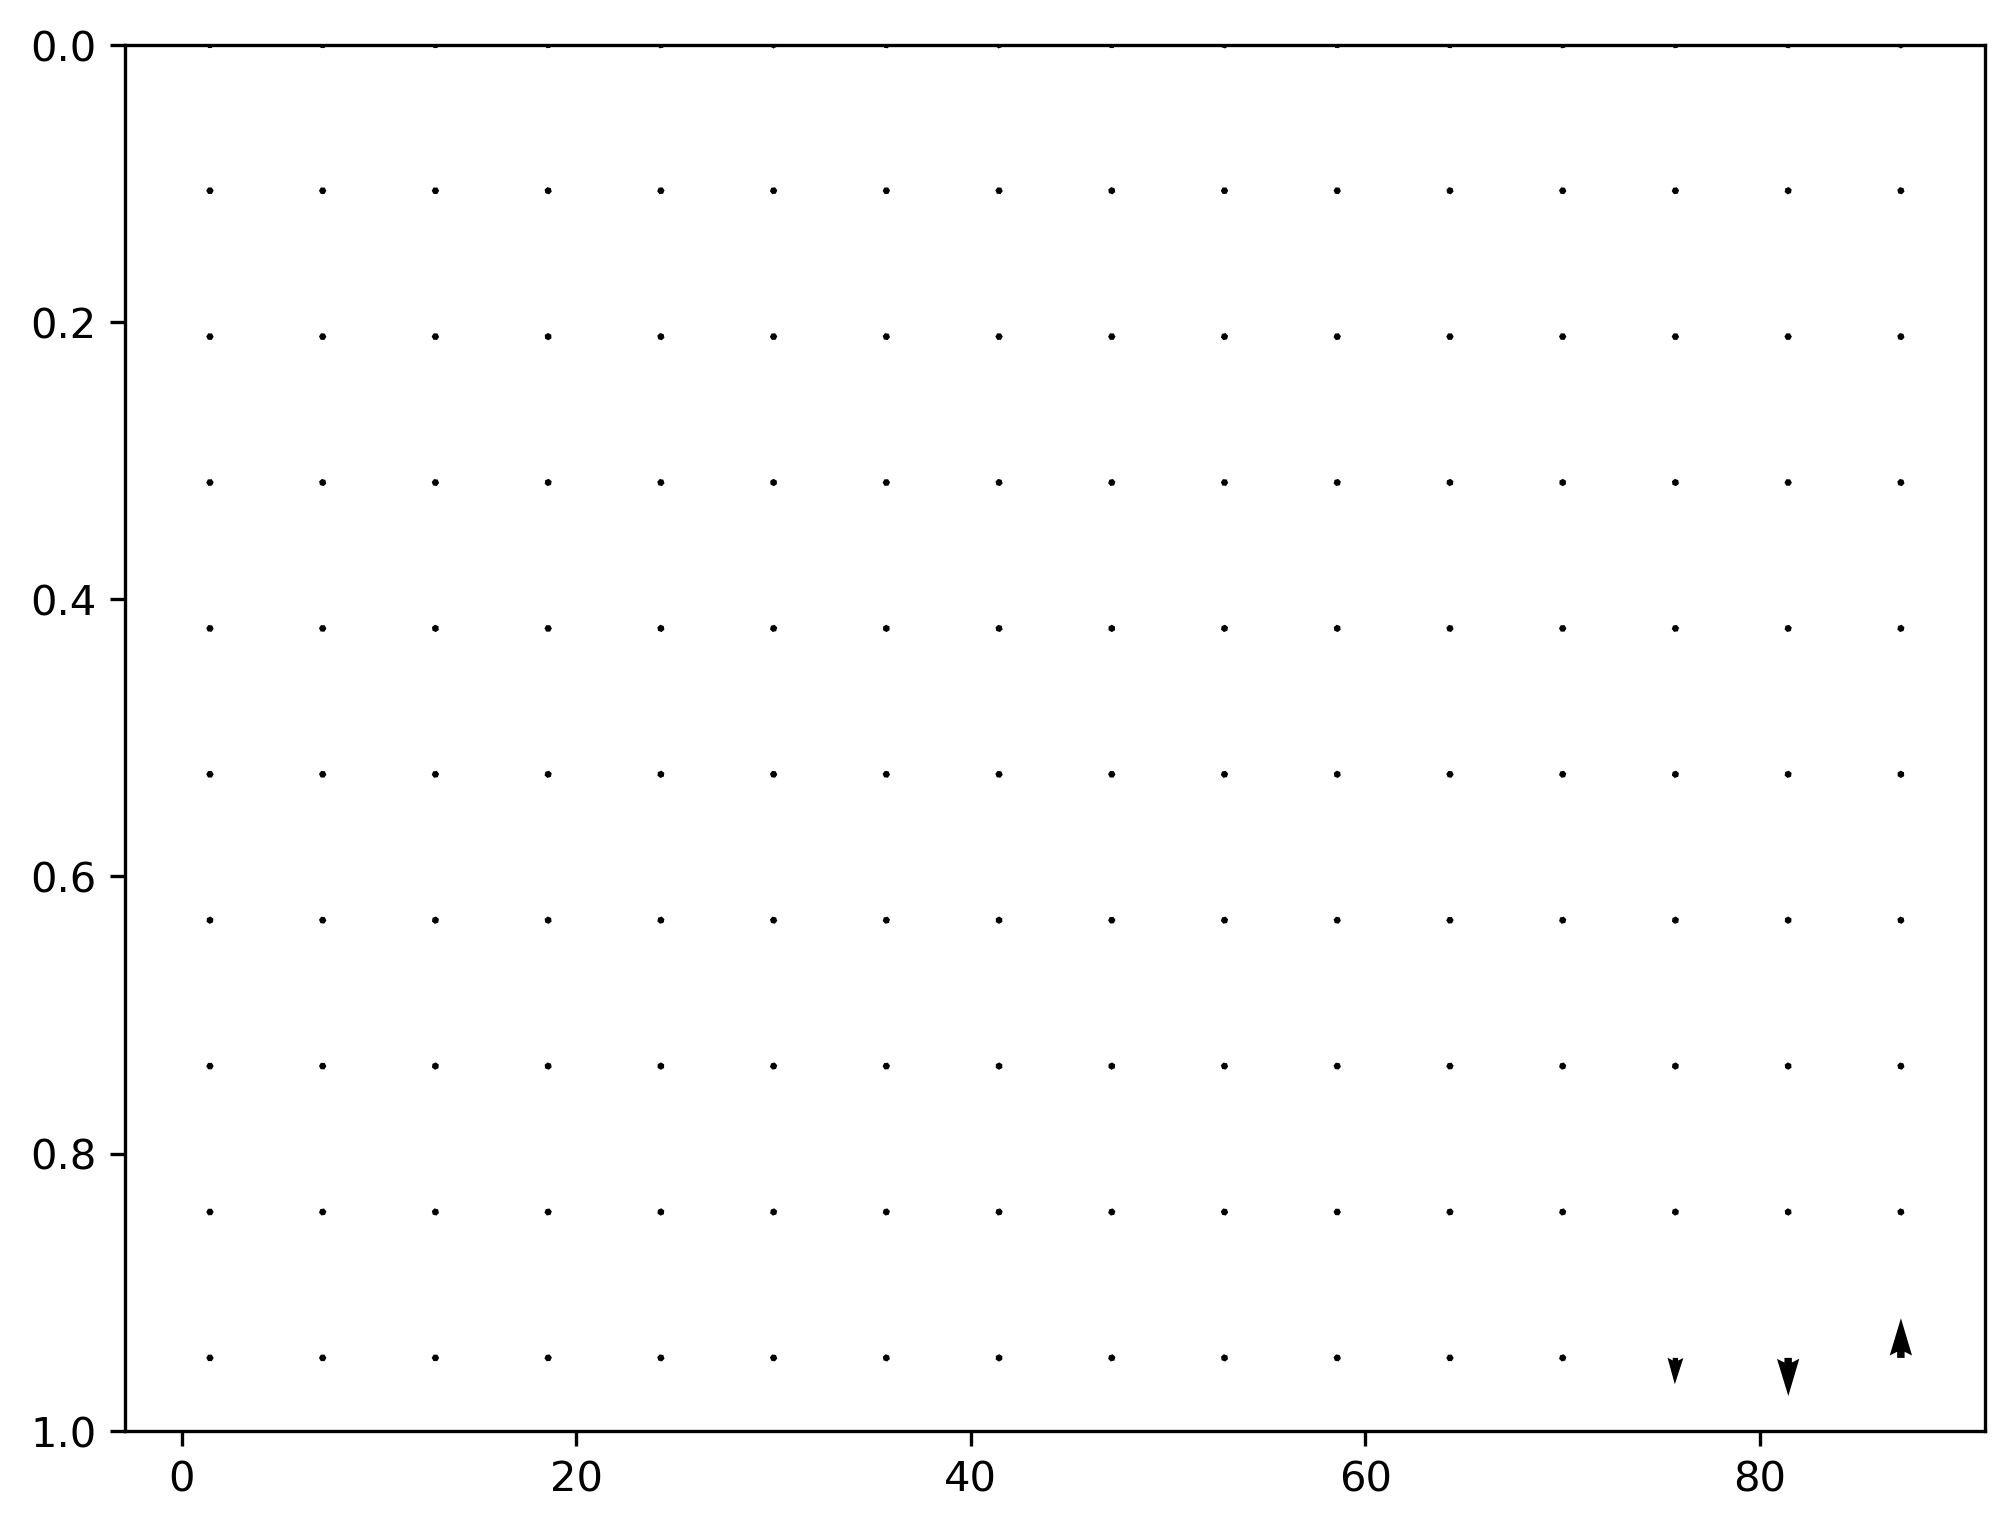

In [37]:
sigma = np.linspace(0,1,20)

y = np.linspace(-90, 90, 64)
yy, zz = np.meshgrid(y, sigma)

fig, ax = plt.subplots(1, figsize=(8,6), dpi=300)

# Plot the difference in EP flux
# ax = axes[j]
# EOF1_PRs = load_EOF(PR, "PC1_results")
# ax.contourf(yy[:,32:], zz[:,32:], -EOF1_PRs, cmap='coolwarm')
NH_idx = 32
threshold = 0

F_j_diff_final = (F_j_mean_diff[0, ::, NH_idx::] )
F_k_diff_final = (F_k_mean_diff[0, ::, NH_idx::] )

# Calculate wind speeds and create a mask for speeds below the threshold
wind_speed = np.sqrt(F_j_diff_final**2 + F_k_diff_final**2)
mask = (wind_speed >= threshold) | (wind_speed <= -threshold)

# Apply the mask to filter out low-speed arrows
F_j_diff_final = np.where(mask, F_j_diff_final, np.nan)
F_k_diff_final = np.where(mask, F_k_diff_final, np.nan)



wind_plt = ax.quiver(yy[::2, NH_idx::2], zz[::2, NH_idx::2], F_j_diff_final[::2, ::2], F_k_diff_final[::2, ::2],
          color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
# ax.quiver(yy[::2, ::2], zz[::2, ::2], -(F_j_mean_diff[::2, ::2]), -(F_k_mean_diff[::2, ::2]),
          # color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)

ax.quiverkey(wind_plt,0.94,1.05,10,r'5 $m^2/s^2$',labelpos='N', labelsep =0.05, color='black')

ax.set_ylim([1, 0])
# ax.set_xlim([10,70])

-0.29197922

In [20]:
import numpy as np

test_all = np.zeros(500)
lag_test = np.arange(0, 10)

# Broadcasting: lag_test[:, None] reshapes it to (10, 1)
test_final = test_all + lag_test[:, None]

print(test_final.shape)  # (10, 500)


(10, 500)


In [21]:
print(test_all.shape)
print(lag_test.shape)
print(test_final.shape)



(500,)
(10,)
(10, 500)


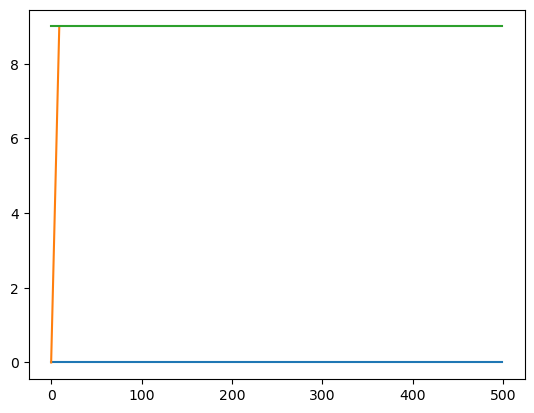

In [25]:
plt.figure()
plt.plot(test_all)
plt.plot(lag_test)
plt.plot(test_final[-1])

